In [115]:
import numpy as np
import matplotlib
import matplotlib.pyplot as pl
import matplotlib.animation as animation
from IPython.display import HTML

from scipy.interpolate import make_interp_spline

import powerbox as pbox
import shoddy

In [2]:
def use_style(dark=True):
    pl.rcdefaults()
    pl.style.use(['custom.mplstyle', 'dark_theme.mplstyle'] if dark else ['custom.mplstyle'])
    pl.rcParams['animation.embed_limit'] = 80.0   # MB, for to_jshtml()

use_style(dark=False)

In [116]:
z     = 9.0
model = shoddy.Model(z=z)

mcl, ls = model.limber_cl(model.matter_power_spectrum)
w_nobias, th_in = model.cf_ang(power_func=model.matter_power_spectrum)
# log-log interpolant so powerbox can evaluate C_ell at any multipole k = ell
_logcl = make_interp_spline(np.log(ls), np.log(np.clip(mcl, 1e-30, None)))
lmin, lmax = ls[0], ls[-1]
def Cl(k):
    k = np.clip(np.atleast_1d(k), lmin, lmax)
    return np.exp(_logcl(np.log(k)))

w_spl = make_interp_spline(th_in * 3600., w_nobias)

In [132]:
# Parameters

L_BOX = np.deg2rad(10)
N_GRID = 512
SEED = 2026
RSMOOTH = 10


In [133]:
box = pbox.LogNormalPowerBox(boxlength=L_BOX, N=N_GRID, dim=2, seed=SEED,
                             pk=Cl)#, vol_normalised_power=False)

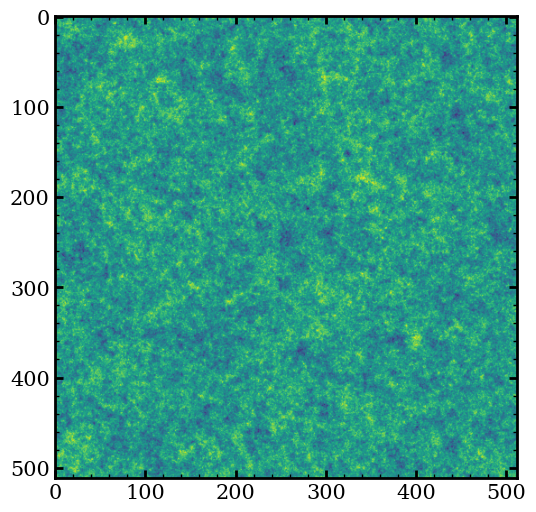

In [134]:
pl.imshow(1+box.delta_x(), norm='log')

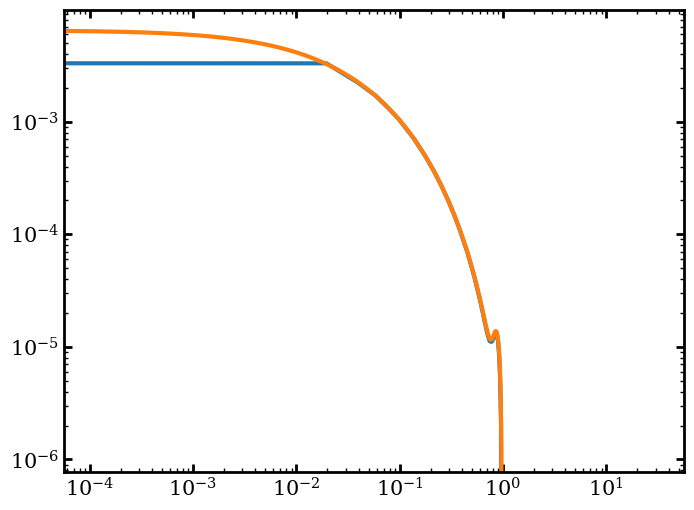

In [135]:
pl.loglog(np.rad2deg(np.arange(N_GRID//2)*L_BOX/N_GRID), box.gaussian_correlation_array()[N_GRID//2,N_GRID//2:])
pl.loglog(th_in, w_nobias)
#pl.xlim(right=300)
#pl.ylim(bottom=1e-2)
pl.show()

In [126]:
th_in*3600

array([2.04604407e-01, 2.07450738e-01, 2.10336665e-01, ...,
       1.99028369e+05, 2.01797130e+05, 2.04604407e+05])